# Module: Supervised Metrics

Unlike scRNA-seq, spatial transcriptomics measurements are affected by the local tissue context.
Transcripts can be captured outside their cell of origin due to transcript diffusion, 3D overlap,
or segmentation inaccuracies, leading to mixed or contaminated expression profiles.
As a result, spatial cells may partially resemble their neighbors.

<center>
 <img src='../_static/img/docs/supervised.png' width='90%' />
</center>

The `supervised` (`sp`) module provides metrics to evaluate how well cell profiles in a spatial
transcriptomics dataset agree with a reference single-cell RNA-seq (scRNA-seq) dataset
with cell type annotations.

By comparing spatial expression profiles to a high-quality scRNA-seq reference,
the supervised module aims to quantify this mismatch. Specifically,
we use the scRNA-seq dataset as a clean reference, transfer cell type labels to the spatial data,
and then compute metrics that measure:
- how well each spatial cell matches its expected cell type,
- how much its expression resembles other (neighboring) cell types, and
- if it is possible to predict that a cell of one cell type is adjacent to a different cell type.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Transfer labels from scRNA-seq to spatial transcriptomics

We first load a spatial transcriptomics dataset (stored as a `SpatialData` object)
and an annotated scRNA-seq reference dataset (stored as an `AnnData` object).
For demonstration purposes, we subset the spatial dataset to a smaller region to reduce runtime.

Next, we initialize a `SegTraQ` object from the SpatialData. During initialization,
the `validate_spatialdata()` method is automatically run to ensure that all required attributes
(e.g. `images_key`, `tables_key`) are correctly specified.

We then transfer cell type labels from the scRNA-seq reference to the spatial dataset
using `run_label_transfer()`. This method computes cell type–specific mean expression
profiles in the reference and assigns each spatial cell to the cell type with the highest
Pearson correlation to its expression profile.

Finally, we define a color scheme for visualizing the transferred cell type labels.

In [3]:
# Load spatial transcriptomics dataset
sdata_ws = sd.read_zarr("../../data/xenium_5K_data/xenium.zarr")

# Subset the dataset to a specific bounding box
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

sdata = sdata_ws.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)

# initialize SegTraQ object
st = segtraq.SegTraQ(sdata, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid")

# Load scRNA-seq dataset
scRNAseq_data_path = Path("../../data/xenium_5K_data/BC_scRNAseq_Janesick.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)

# Define color palette for cell types
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

no parent found for <ome_zarr.reader.Label object at 0x7ffe4238ecf0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe42296ad0>: None
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:1808: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control and low-quality transcripts from the SpatialData object in-place. Set filter_kwargs={'inplace': False} to avoid modifying the original object.
  sdata_new = _filter_control_and_low_quality_transcripts(


The transferred labels are stored in `sdata.tables[tables_key].obs["transferred_cell_type"]`.
The column name can be changed via the `cell_type_key` argument.

By default, cells with **≤ 10 or ≥ 2000 transcripts** and **≤ 5 detected genes** are filtered out.
These thresholds can be adjusted using `tx_min`, `tx_max`, `gn_min`, and `gn_max`.

Ensure that gene identifiers match between `adata_ref.var_names` and
`sdata.tables[tables_key].var_names`. If they differ, specify the corresponding
identifier columns using `ref_ensemble_key` and `query_ensemble_key`.
If these are left as `None` (default), `var_names` are used.

In [4]:
st.run_label_transfer(
    adata_ref,
    ref_cell_type="celltype_major",  # Reference cell type column
    ref_raw_counts_layer="raw",  # Reference raw counts layer
)

Next, cell shapes can be plotted and colored by cell type based on a defined color palette.
Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer);
for compatibility with `spatialdata-plot`, we replace missing values (`NaN`) with "Unknown" before plotting.

In [5]:
# Replace NaN with Unknown
s = st.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st.sdata.tables["table"].obs["transferred_cell_type_plot"] = s.fillna("Unknown")

labels = st.sdata.tables["table"].obs["transferred_cell_type_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

/tmp/ipykernel_3243343/964490482.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


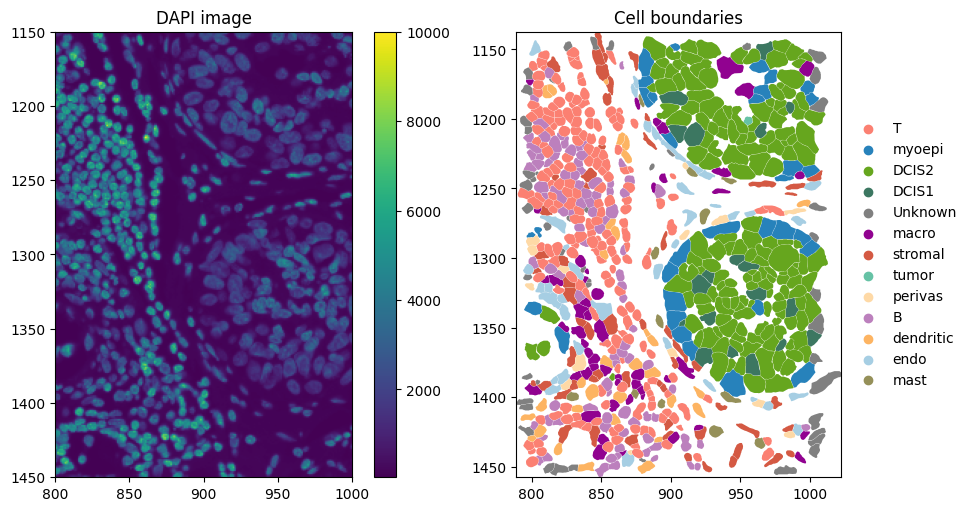

In [6]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
st.sdata.pl.render_images("image").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Add link between table and spatial element
st.sdata.tables["table"].obs["region"] = "cell_boundaries"
st.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",  # outlines visible on black
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries", coordinate_systems="global")

#### Computing cell type-specific markers

**Positive markers** are genes that are consistently upregulated in one cell type relative to other cell types.
To avoid composition bias arising from unequal cell type abundances, we perform
**pairwise comparisons between all cell types** in the reference dataset.
Marker detection can be performed using either differential expression (`mode="de"`) or
AUC-based scoring (`mode="auc"`).

For each cell type, genes are selected by a voting scheme: a gene must be identified as
upregulated in at least a fraction of pairwise contrasts (`vote_fraction_pos`, default = 0.5).
To ensure that positive markers are representative of the cell type rather than driven
by a small subset of cells, we additionally require that a gene is expressed (> 0) in at least
`min_pos_frac` (default = 0.1) of cells of that type. To further increase specificity,
we require that a positive marker is not shared by more than `t_pos × n_celltypes` cell types.
This yields markers that are both upregulated and cell-type–specific,
without bias from cell type composition in the reference data.

**Negative markers** are derived from the same pairwise contrasts but are defined as genes that
are effectively off in a focal cell type while being upregulated elsewhere. For each ordered pair of
cell types `(a, b)`, genes that are upregulated in `a` relative to `b` are considered negative-marker
candidates for `b` if they are expressed (`> 0`) in at most `max_neg_frac` (default = 0.05)
of cells of type b. To avoid ambiguous genes with inconsistent directionality,
we further require that a negative marker of `b` is not identified as upregulated in `b` relative
to any other cell type across all ordered contrasts.

When using `mode="auc"`, the minimum required AUC can be set via `auc_pos_thresh` (default = 0.9).
When using `mode="de"`, the differential expression method can be selected via `method`
(`"wilcoxon"`, `"t-test"`, or `"logreg"`), with thresholds defined by `logFC_pos_thresh`
(default = 1.0) and `pval_adj_thresh` (default = 0.05).

All computations can be parallelized by specifying the number of jobs via `n_jobs`.

In [7]:
# get cell type-specific markers from the reference dataset
markers = st.markers_from_reference(
    adata_ref,
    ref_cell_type="celltype_major",
    ref_raw_counts_layer="raw",
    mode="de",
    vote_fraction_pos=0.5,
    min_pos_frac=0.1,
    max_neg_frac=0.05,
    n_jobs=16,
)

A list of positive and negative markers computed for each cell type is shown below.

In [8]:
for cell_type, sign in markers.items():
    pos = sign["positive"]
    neg = sign["negative"]

    print(f"{cell_type}  |  positive: {', '.join(pos)}")
    print(f"{cell_type}  |  negative: {', '.join(neg)}\n")

B  |  positive: PAX5, MS4A1, BANK1, FCRL1, BLK, FCRL2, AIM2, TNFRSF13B, CD19, POU2AF1, SCIMP, FCRL5, P2RX5, CD79A, PARP15, CD79B, TNFRSF13C, POU2F2, FCRLA, STAP1, CD22, COL4A3, SP140, NIBAN3, CR1, ADAM28, PLCG2, FCMR, CD40, TLR6, ST6GAL1, DERL3, KCNN4, CD27, CD52, ITGB7, BLNK, CNR2, COL4A4, SPIB, IRF4, TNFRSF17, ZBP1, PTK2B, FCGR2B, CDK14, PTPN6, TNFAIP8, SP110, ATM, FCRL3, COCH, CCDC141, NCF1, CD38, CCR6, ITGAL, RELT, PIM2, SMCHD1, ANKRD13A, NCOA3, PDK1, LRRK2, KCNA3, NLRP1, TLR1, SLAMF1, SLAMF6, GPR174, JAK3, GRK5, NLRC5, SMAP2, BCL2, SYVN1, TENT5C, ORAI2, CASP10, CYSLTR1, CD83, LPXN, TRAF5, REL, BTN3A1, SYNRG, ATP2B1, SEMA4B
B  |  negative: ABCA10, ABCA8, ABCC8, ABCC9, ABI3BP, AC007906.2, ACVRL1, ADAM12, ADAM33, ADAMDEC1, ADAMTS1, ADAMTS12, ADAMTS14, ADAMTS2, ADAMTS4, ADAMTS5, ADCYAP1, ADGRE2, ADGRL4, ADORA2B, ADORA3, ADRA1B, ADRA2A, ADTRP, AFAP1L2, AGR3, AIF1, ALDH7A1, ALPK3, ALPL, ANGPT1, ANGPTL2, ANGPTL4, ANXA3, ANXA8, APLNR, AQP1, ASPN, ATL1, AVPR1A, AXIN2, BAALC, BARX2, BCL6B, 

Below, we show the number of negative markers that overlap with the positive markers of each cell type.
To reliably estimate contamination, each cell type should share **at least ~5 negative markers**
with the positive marker set of every other cell type. If these overlaps are too small,
contamination estimates become unstable.

In such cases, the marker definition can be relaxed by adjusting the thresholds used in
`markers_from_reference` above.

In [9]:
ctypes = list(markers.keys())
overlap_df = pd.DataFrame(0, index=ctypes, columns=ctypes, dtype=int)

for c in ctypes:
    neg_c = set(markers[c].get("negative", []))
    for d in ctypes:
        pos_d = set(markers[d].get("positive", []))
        overlap_df.loc[d, c] = len(pos_d & neg_c)

overlap_df

,B,DCIS1,DCIS2,T,dendritic,endo,macro,mast,myoepi,perivas,stromal,tumor
B,0,50,48,41,26,44,29,47,41,49,48,57
DCIS1,49,0,20,75,50,37,48,50,12,41,37,23
DCIS2,39,16,0,78,41,27,40,56,5,29,25,12
T,26,48,52,0,27,37,24,43,33,28,47,66
dendritic,50,66,63,73,0,49,42,70,48,53,56,70
endo,108,90,92,110,101,0,94,86,63,45,66,95
macro,71,76,74,102,49,60,0,74,48,79,54,88
mast,28,27,29,37,24,24,20,0,20,28,27,30
myoepi,97,33,58,98,85,55,85,70,0,59,61,75
perivas,87,49,60,109,70,6,80,92,34,0,24,71


#### Compute marker purity

We quantify how pure each spatial cell’s expression profile is with respect to its assigned
cell type using positive and negative marker genes.

We assume that differences between scRNA-seq and spatial transcriptomics profiles arise
primarily from local contamination by neighboring cells (e.g. diffusion or segmentation spillover).
This motivates evaluating negative markers in a neighborhood-aware manner.

**Identity evaluation**

For each cell of type `c`, we compute the fraction of positive marker genes
(`markers[c]["positive"]`) that are expressed in the cell (`> 0`).
This quantity, `positive_marker_recall`, measures how consistently the cell expresses
markers expected for its assigned type and is computed independently of the neighborhood.

**Contamination (neighborhood-aware)**

For a focal cell, we identify the cell types present in its spatial neighborhood and
intersect the focal cell type’s negative markers with the positive markers of neighboring cell types.
Optionally, these markers can be further restricted to genes that are expressed in at least one
neighboring cell of the corresponding source type (`require_neighbor_expression=True`).
These relevant negative markers represent genes that should be absent from the focal cell
but present in nearby cells. The metric `negative_marker_avoidance` is defined as
the fraction of these markers that are not expressed in the focal cell.

If no neighborhood graph is present (`neighbors_key not in sdata.tables[tables_key].obsp`),
it is automatically computed from cell centroids using a Delaunay graph.

**Overall purity**

Identity and contamination are combined using:

`marker_balanced_accuracy = 0.5 * (positive_marker_recall + negative_marker_avoidance)`

This corresponds to balanced accuracy, i.e. the mean of sensitivity (positive marker recall)
and specificity (negative marker avoidance). High values indicate strong expression of
expected markers together with minimal expression of markers attributable to neighboring cell types.

In [10]:
purity = st.sp.marker_purity(
    cell_type_key="transferred_cell_type",
    markers=markers,
    require_neighbor_expression=True,
    neighbors_key="spatial_connectivities",
)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:1615: RuntimeWarning: neighbors_key='spatial_connectivities' not found in adata.obsp. A neighborhood graph based on Delaunay will be computed.
  return sp.marker_purity(


##### `negative_marker_avoidance`

In [11]:
def boxplot_per_celltype(
    sdata,
    feature,
    celltype_col="transferred_cell_type",
    q=1.0,
    figsize=(10, 5),
    ascending=True,
    palette=None,
):
    obs = sdata.tables["table"].obs
    df = obs[[celltype_col, feature]].dropna().copy()

    if q < 1:
        df = df[df[feature] <= df[feature].quantile(q)]

    # order by median (low -> high). Use .sort_values(ascending=False) for high -> low
    order = df.groupby(celltype_col)[feature].median().sort_values(ascending=ascending).index.tolist()

    # ensure palette covers all categories (optional safety)
    if palette is not None:
        palette = {ct: palette.get(ct, "#808080") for ct in order}

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df,
        x=celltype_col,
        y=feature,
        order=order,
        hue=celltype_col,
        palette=palette,
        showcaps=True,
        showfliers=False,
        legend=False,
        ax=ax,
    )

    sns.stripplot(
        data=df,
        x=celltype_col,
        y=feature,
        order=order,
        hue=celltype_col,
        palette=palette,
        jitter=0.25,
        dodge=False,
        alpha=0.6,
        edgecolor="black",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Cell type")
    ax.set_ylabel(feature)
    fig.tight_layout()
    plt.show()

The `negative_marker_avoidance` score indicates that cells of type DCIS1 are the most contaminated.

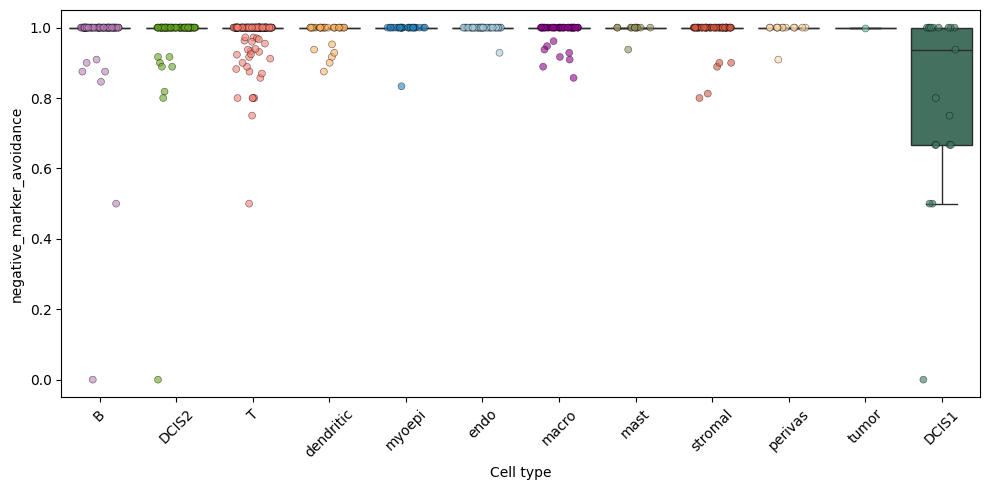

In [12]:
boxplot_per_celltype(st.sdata, feature="negative_marker_avoidance", palette=col_celltype, ascending=False)

This can also be visualized spatially. The `negative_marker_avoidance` score is only computed
for cells which have a neigbhor of a different type. This clearly shows the DCIS1 cells with
low `negative_marker_avoidance` score, i.e. contamination.

WARNING  render_shapes: Found 160 NaN values in color data. These observations will be colored with the 'na_color'.


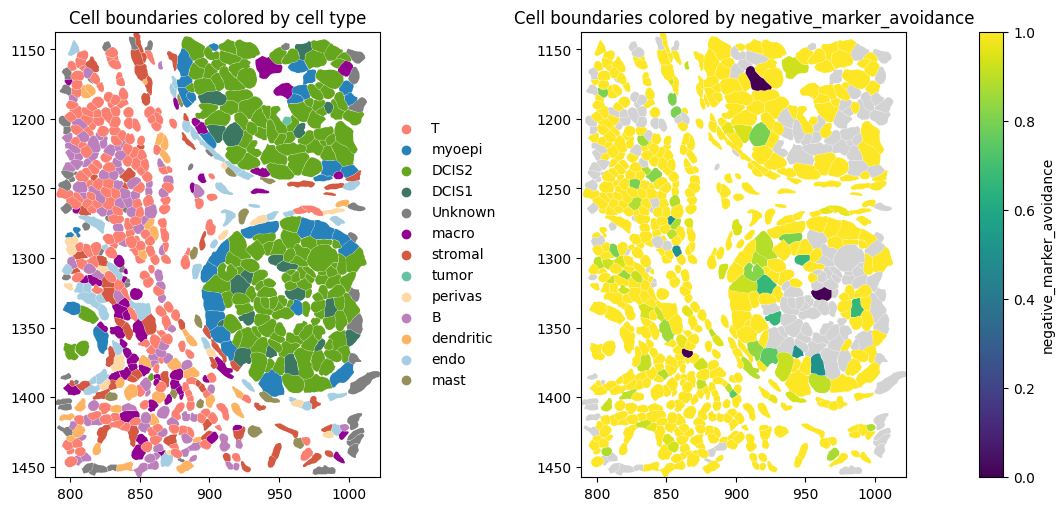

In [13]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="negative_marker_avoidance",
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by negative_marker_avoidance", coordinate_systems="global")

##### `positive_marker_recall`

Cells annotated as mast and DCIS2 show the highest `positive_marker_recall` scores,
suggesting that their cell identity is captured most consistently by positive markers.

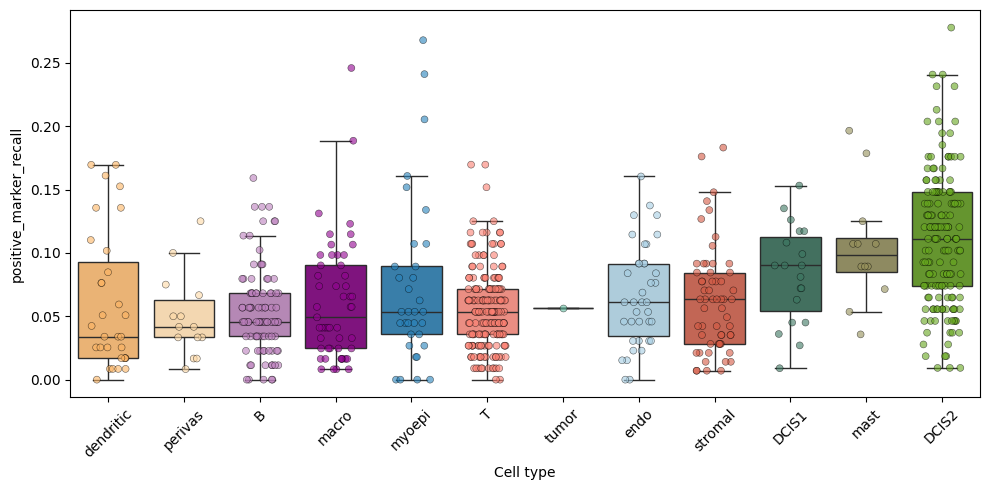

In [14]:
boxplot_per_celltype(st.sdata, feature="positive_marker_recall", palette=col_celltype)

The `positive_marker_recall`score is computed globally, i.e. irrespective of the cell neighborhood,
so there are fewer missing values than for `negative_marker_avoidance`.
The spatial plot below is in line with the boxplot above, showing that cells of type DCIS2
and mast show the highest `positive_marker_recall`.

WARNING  render_shapes: Found 47 NaN values in color data. These observations will be colored with the 'na_color'. 


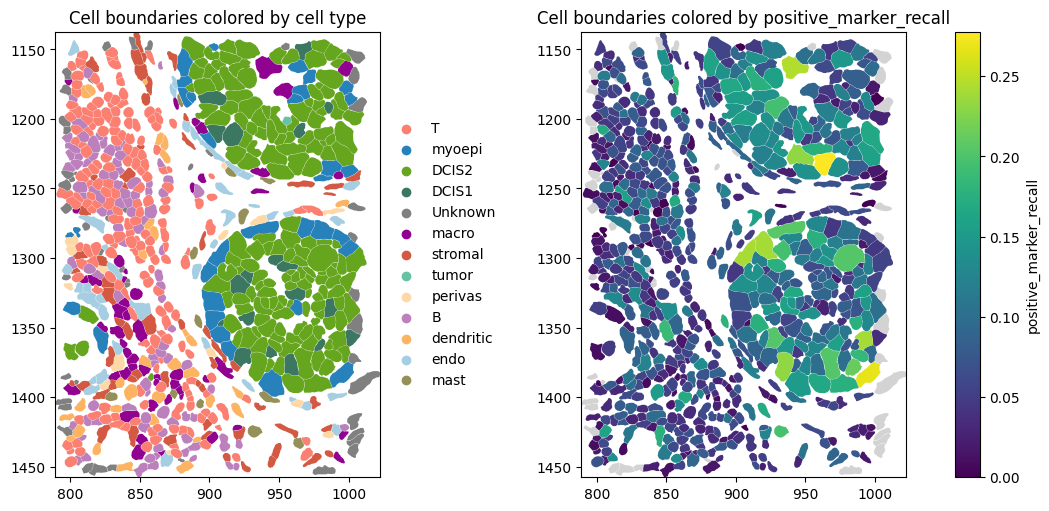

In [15]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="positive_marker_recall",
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by positive_marker_recall", coordinate_systems="global")

##### `marker_balanced_accuracy`

Cells of type **DCIS1** (which have high transcript counts) show the highest
`negative_marker_avoidance` and the third-highest `positive_marker_recall`.
This is expected: cells with higher transcript counts tend to capture more positive markers,
but also have a higher risk of capturing negative markers. As a result,
the combined metric `marker_balanced_accuracy`, which balances `positive_marker_recall`
and `negative_marker_avoidance`, provides a more representative measure of purity.
Accordingly, **DCIS1** ranks among the cell types with the lowest purity,
while **DCIS2** and **mast** cells show the highest purity.

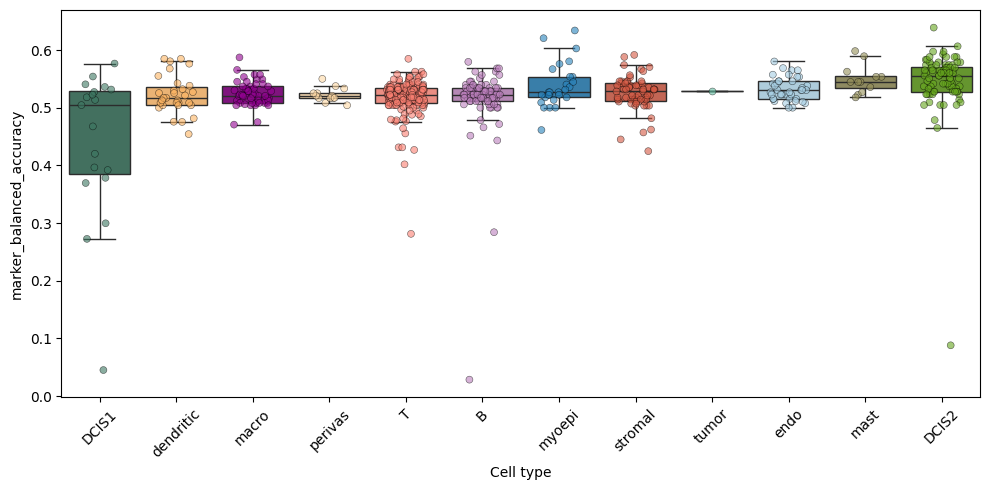

In [16]:
boxplot_per_celltype(st.sdata, feature="marker_balanced_accuracy", palette=col_celltype)

#### Neighborhood contamination

Marker purity summarizes how well a cell matches its own markers and avoids
neighborhood-relevant negatives. In many cases, we also want to quantify
(i) **how many contaminating transcripts** are present per cell and
(ii) **which neighboring cell types** contribute to this signal.
We therefore compute neighborhood contamination.

We treat a gene as contamination-relevant for a target cell type `c_tgt` if it is
(i) a **negative marker of `c_tgt`**,
(ii) simultaneously a **positive marker of a neighboring source type `c_src`**, and
(iii) actually **expressed (>0) in at least one of the neighboring cells of the source type**
(`require_neighbor_expression` , default=True).

This yields two levels of output:

**Per-cell metrics.**
For each cell, we compute
- `contamination_counts`: the total number of transcripts for contamination-relevant genes, and
- `contamination_strength`: the fraction of transcripts assigned to the cell that
correspond to contamination-relevant genes, computed as `contamination_counts` / `total_transcript_counts`.

**Directed cell-type contamination (stored in `.uns`):**
Across all cells, we additionally summarize contamination between source and target cell types:
- `contamination_matrix`: the fraction of target cells of type `c_tgt` that contain at
least one contamination-relevant transcript originating from source cell type `c_src`, and
- `contamination_strength_matrix`: the mean contamination strength of target
cells of type `c_tgt` attributable to source cell type `c_src`, computed by
averaging the source-specific contamination strength across all evaluable target cells.
- `contamination_evaluable_cells_matrix` : Directed source-to-target matrix.
Entry (c_src, c_tgt) is the number of target cells for which contamination from source type c_src could be evaluated.

If no neighborhood graph is present (`neighbors_key not in sdata.tables[tables_key].obsp`),
it is automatically computed from cell centroids using a Delaunay graph.

In [17]:
_, _, _, _ = st.sp.neighbor_contamination(
    cell_type_key="transferred_cell_type",
    markers=markers,
    require_neighbor_expression=True,
    neighbors_key="spatial_connectivities",
    inplace=True,
)

##### `contamination_counts`

The spatial plot below shows, for each target cell, the number of contaminating transcripts.
If desired, this quantity can be normalized by the total number of transcripts per cell.
As expected, the plot correlates with the `negative_marker_avoidance`score from above.

WARNING  render_shapes: Found 160 NaN values in color data. These observations will be colored with the 'na_color'.


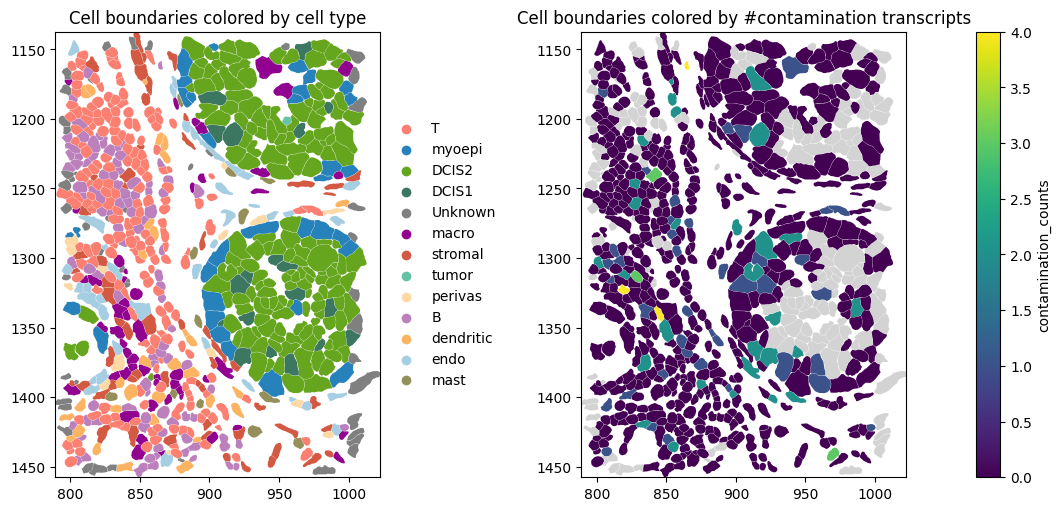

In [18]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="contamination_counts",
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by #contamination transcripts", coordinate_systems="global")

##### `contamination_strength`

In addition, we can visualize `contamination_strength`, the fraction of transcripts
assigned to a cell that correspond to locally relevant contamination marker genes.
A value of contamination_strength = 0 indicates that no contamination-relevant
transcripts were detected, whereas larger values indicate that a greater proportion of
the cell's assigned transcripts are consistent with potential contamination from neighboring cells.

WARNING  render_shapes: Found 160 NaN values in color data. These observations will be colored with the 'na_color'.


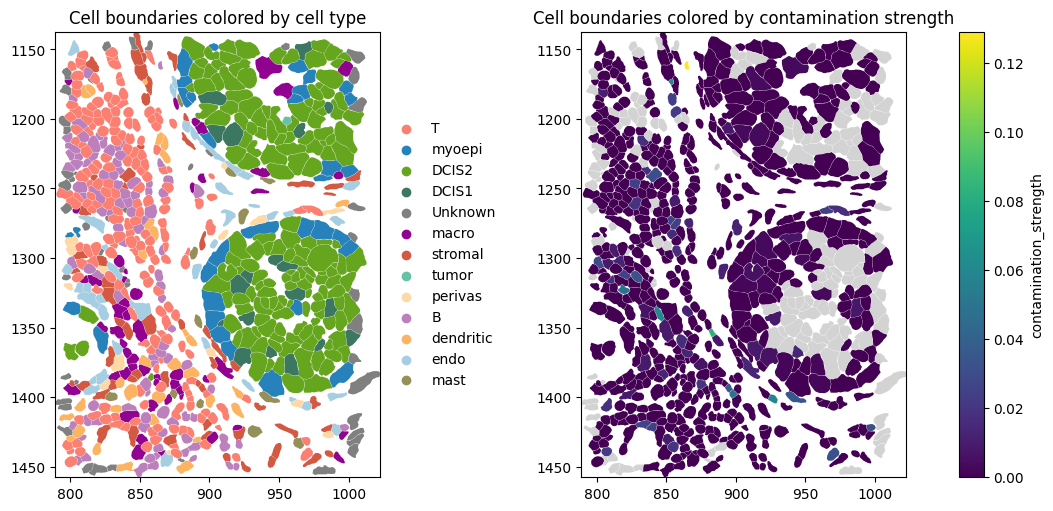

In [19]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    palette=cols,
    groups=labels,
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[0], title="Cell boundaries colored by cell type", coordinate_systems="global")

st.sdata.pl.render_shapes(
    "cell_boundaries",
    color="contamination_strength",
    outline_color="white",
    outline_width=0.5,
).pl.show(ax=axes[1], title="Cell boundaries colored by contamination strength", coordinate_systems="global")

##### `.uns["contamination_matrix"]`

The heatmap below shows, for each source–target cell-type pair, the
**fraction of all target cells** contaminated by transcripts from a neighboring source cell type.

Percentages within a column may sum to more than 100% because a single target cell
can be contaminated by **multiple** neighboring source cell types and is therefore counted for each of them.

The bubble plot illustrates why both the contamination frequency (bubble color) and the number
of evaluable target cells (bubble size) should be considered when interpreting directed contamination.
For example, approximately 20% of evaluable T cells are contaminated by stromal cells,
providing evidence for a common contamination pattern across many cells.
In contrast, although 100% of evaluable T cells are contaminated by DCIS2 cells,
this result is based on only a small number of evaluable T cells because few T cells have
neighboring DCIS2 cells with relevant marker genes. Consequently,
high contamination frequencies based on very few evaluable cells should be interpreted with caution.

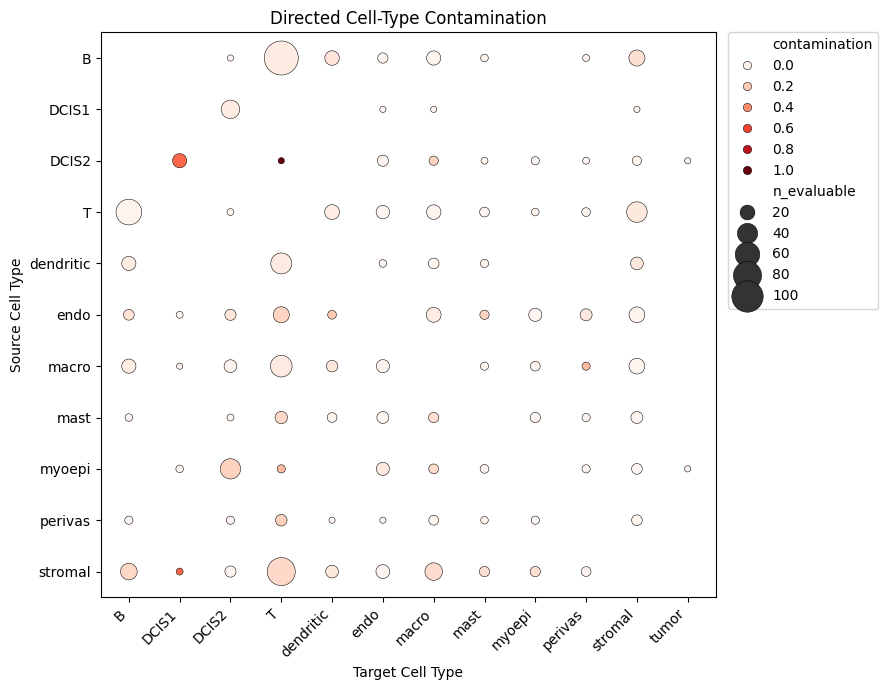

In [20]:
cont_mat = st.sdata.tables[st.tables_key].uns["contamination_matrix"]
cont_n = st.sdata.tables[st.tables_key].uns["contamination_evaluable_cells_matrix"]

plot_df = (
    cont_mat.stack(dropna=False)
    .rename("contamination")
    .reset_index()
    .rename(columns={"level_0": "source", "level_1": "target"})
)

plot_df["n_evaluable"] = cont_n.stack(dropna=False).values

plt.figure(figsize=(9, 7))

ax = sns.scatterplot(
    data=plot_df,
    x="target",
    y="source",
    size="n_evaluable",
    hue="contamination",
    sizes=(20, 600),
    palette="Reds",
    edgecolor="black",
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Directed Cell-Type Contamination")
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### `.uns["contamination_strength_matrix"]`

The heatmap below summarizes contamination strength for each source–target cell-type pair.
Each entry represents the mean contamination strength across all evaluable target cells of the
given target cell type, where the source-specific contamination strength is computed as the
fraction of transcripts in the target cell that correspond to contamination-relevant markers of the source cell type.

The bubble plot of the `contamination_strength_matrix` provides complementary information by quantifying
how large the contamination signal is when it occurs. For example, although myoepithelial and DCIS2 cells
are frequently neighbors, contamination from DCIS2 into myoepithelial cells is negligible.
Moreover, relatively few myoepithelial cells are evaluable for DCIS2 despite their spatial
proximity because the two cell types share only a small number of mutually exclusive markers
(four in this example; see `overlap_df`), and these markers may not be expressed in the
neighboring DCIS2 cells in every local neighborhood.

This can have both technical and biological causes. For example, when two cell types have similar
expression profiles, contamination between them is less consequential because the
contaminating transcripts largely match the expected expression of the target cell.


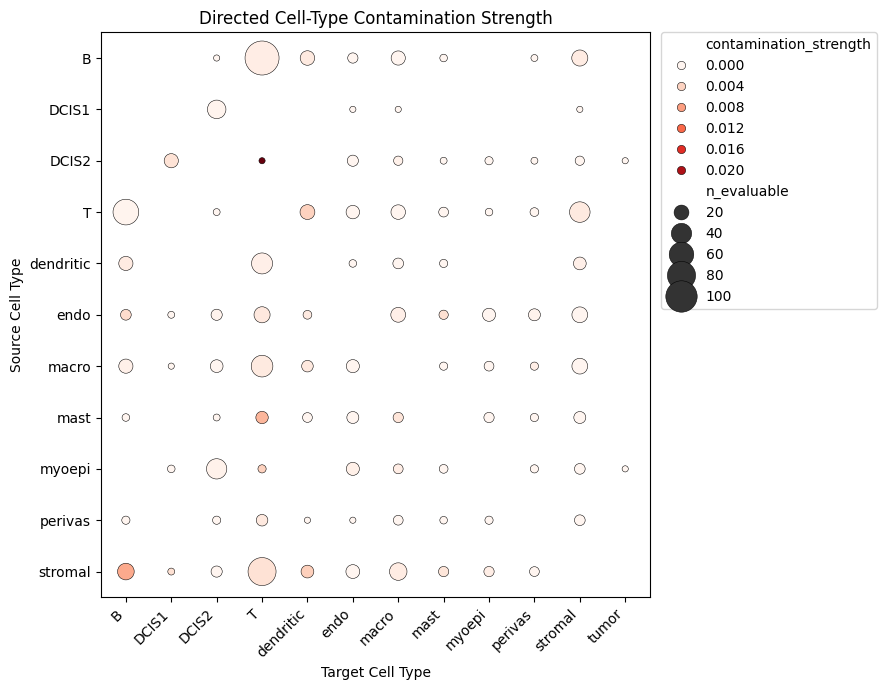

In [21]:
cont_strength_mat = st.sdata.tables[st.tables_key].uns["contamination_strength_matrix"]

plot_df = (
    cont_strength_mat.stack(dropna=False)
    .rename("contamination_strength")
    .reset_index()
    .rename(columns={"level_0": "source", "level_1": "target"})
)

plot_df["n_evaluable"] = cont_n.stack(dropna=False).values

plt.figure(figsize=(9, 7))

ax = sns.scatterplot(
    data=plot_df,
    x="target",
    y="source",
    size="n_evaluable",
    hue="contamination_strength",
    sizes=(20, 600),
    palette="Reds",
    edgecolor="black",
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Directed Cell-Type Contamination Strength")
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### **! Important**
The observed contamination between two cell types is influenced by three main factors:

1) **True contamination**, i.e. transcript spillover or transcript misassignment between neighboring cells.
2) **Spatial proximity**, i.e. how frequently the two cell types occur as neighbors.
The more often they are adjacent, the greater the opportunity for contamination.
3) **Expression similarity**, .ie. contamination between transcriptionally similar
cell types is both less consequential and more difficult to detect.
Because the two cell types share fewer mutually exclusive marker genes,
transferred transcripts have less impact on the measured expression profile,
and fewer informative genes are available for quantifying contamination.

#### Compute mutually exclusive co-expression rate (MECR)

The `mutually_exclusive_coexpression_rate` function assesses mutual exclusivity between
marker genes using Fisher’s exact test on binary gene detection (expression `> 0`).
Candidate pairs are constructed as unique, unordered combinations of positive and negative
markers across cell types, excluding gene pairs that co-occur as positive markers in any cell type.
Fisher’s exact test with `alternative="less"` is used to test whether genes co-occur less often
than expected under independence, while odds ratios are reported with a pseudocount correction
to avoid infinities in sparse data. By conditioning on the marginal detection frequencies of each gene,
Fisher’s exact test does not favor methods with low overall transcript counts.

In [22]:
mecr = st.sp.mutually_exclusive_coexpression_rate(
    markers=markers,
    pseudocount=0.5,
    inplace=True,
)

/tmp/ipykernel_3243343/1855350009.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


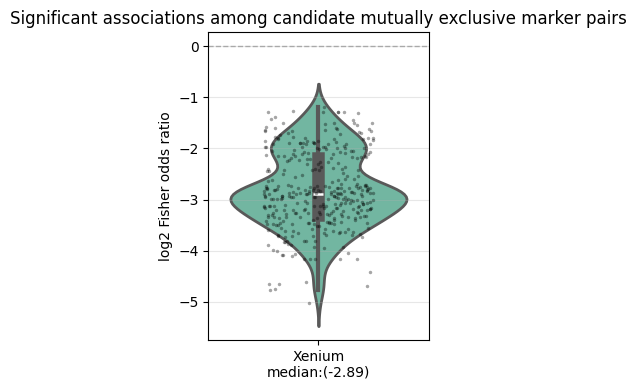

In [23]:
rows = []

tbl = st.sdata.tables["table"]
mecr_df = tbl.uns["mutually_exclusive_coexpression_rate"]

# Filter significant, finite odds ratios and p-values
df_sig = mecr_df[
    mecr_df["odds_ratio"].notna()
    & np.isfinite(mecr_df["odds_ratio"])
    & mecr_df["pvalue"].notna()
    & np.isfinite(mecr_df["pvalue"])
    & (mecr_df["pvalue"] < 0.05)
]

# Build rows
rows.extend({"method": "Xenium", "Fisher_OR": np.log2(row["odds_ratio"])} for _, row in df_sig.iterrows())

df = pd.DataFrame(rows)

median_order = df.groupby("method")["Fisher_OR"].median().sort_values().index.tolist()

# Compute medians in plotting order
medians = df.groupby("method")["Fisher_OR"].median().reindex(median_order)

# Build x-axis labels with medians
xtick_labels = [f"{m}\nmedian:({medians[m]:.2f})" for m in median_order]

plt.figure(figsize=(3, 4))

# --- Violin plot ---
ax = sns.violinplot(
    data=df,
    x="method",
    y="Fisher_OR",
    order=median_order,
    palette="Set2",
    linewidth=2,
)

# --- Stripplot overlay ---
sns.stripplot(
    data=df,
    x="method",
    y="Fisher_OR",
    order=median_order,
    color="black",
    size=2.5,
    alpha=0.35,
    jitter=0.25,
    ax=ax,
)

# Reference line: OR = 1
ax.axhline(0, ls="--", lw=1, color="gray", alpha=0.6)

# Apply new x-axis labels
ax.set_xticklabels(xtick_labels)

ax.set_ylabel("log2 Fisher odds ratio")
ax.set_xlabel("")
ax.set_title("Significant associations among candidate mutually exclusive marker pairs")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Run all metrics.

In [24]:
st.run_supervised(
    adata_ref=adata_ref,
    ref_cell_type="celltype_major",
    ref_raw_counts_layer="raw",
)

## Session Info

In [25]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.8.0
0.4.0
